
# 02425 Diffusion and stochastich differential equations


## WEEK 2: Probability

In [1]:
import numpy as np
import random
from matplotlib import pyplot as plt

In this exercise today we will work with measure therory, specificially the Lebesgue measure on the product set on $\mathbb{R}^{2}$.

### Exercise 1

We are working on a measurable space $(\Omega ,F ,P)=([0,1]^{2},B (\mathbb{R}),P)$, where $P$ is the Lebesgue measure on the product space. The lebesgue measure is essentialy the area of the set that its measuring.

Assume an observation on the product space is given by $\omega =(x ,y)$ and define the following variables.

$$X (\omega)=x $$

$$Y (\omega)=y $$

$$Z (\omega)=x +y $$

We are now interested in finding $P (X \in A)$, which is defined as $P ({\{\omega \in \Omega \colon X (\omega)\in A \}})$. Since we are intersted in showing that $X(\omega)$ is distributed as a uniform distribution, we will look at the set given as $[a,b]$, where $a ,b \in [0,1]$ and $a<b$.

$$P (X \in [a,b])=P ({\{\omega \in \Omega \colon X (\omega)\in [a,b] \}})=\int_{a}^{b}\int_{0}^{1}d y d \textcolor{white}{x}=b-a$$

A visual argument can be shown below.

<p align="center"><img src="Images\Xw.jpg" width="300"></p>

Which we can see is the Uniform distribution (per definition of the uniform distrinbution). Now let $[a',b']$, where $a' ,b' \in [0,1]$ and $a'<b'$, and consider the following.

$$P (Y \in [a',b'])=P ({\{\omega \in \Omega \colon X (\omega)\in [a',b'] \}})=\int_{a'}^{b'}\int_{0}^{1}d x d \textcolor{white}{y}=b'-a'$$


Which agains shows that the variable Y is a random distribution. Now we will investigate the following:

$$P(\{\omega \in \Omega \colon X(\omega) \in A, Y(\omega) \in A\}) = P(\{\omega \in \Omega \colon X(\omega) \in [a, b], Y(\omega) \in [a', b']\}) = \int_{a}^{b} \int_{a'}^{b'} dy \, d\textcolor{white}{x} = (b' - a')(b - a) = P(\{\omega \in \Omega \colon X(\omega) \in A\}) \cdot P(\{\omega \in \Omega \colon Y(\omega) \in A\})$$


Which concludes that the two variables $X$ and $Y$ are independent. A visual figure of the join set is given below.

<p align="center"><img src="Images\XwYw.jpg" width="300"></p>

### Exercise 2

The level set is defined as the subset of the space, where the function attaines the same value. Since we are working on a 3 dimensional space this can be seen as the curves on the domain where the function value of the variable are constant. In another litteratur this is also named the conotur levels.

We show the solutions of this be the conotur plots of the functions.

Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 2.0]), which exceeds Locator.MAXTICKS (1000).


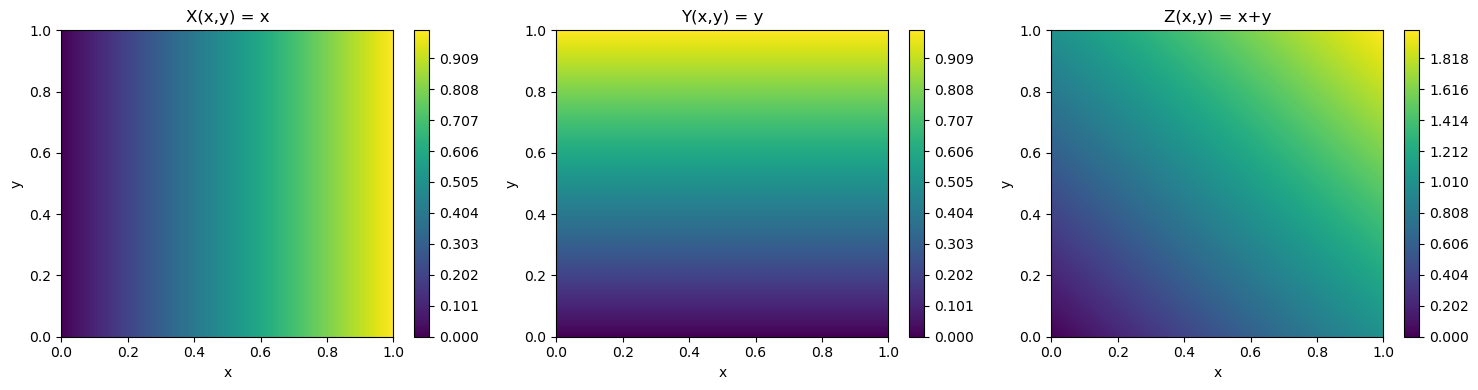

In [2]:
def X(x, y):
    return x

def Y(x, y):
    return y

def Z(x, y):
    return x+y

x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)

import matplotlib.pyplot as plt

xx, yy = np.meshgrid(x, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, f, title in zip(
    axes,
    [X, Y, Z],
    ["X(x,y) = x", "Y(x,y) = y", "Z(x,y) = x+y"]
):
    contour = ax.contourf(xx, yy, f(xx, yy), levels=1000, cmap="viridis")
    fig.colorbar(contour, ax=ax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Exercise 3

We are interested in calculating (numerically) the following expectation, gives as $\mathbb{E}\left\{ Z \mid X \in \left[\frac{i-1}{n}, \frac{i}{n}\right] \right\}$.

The exercise choses $n=10$, and we let $i = 1,2,3...n$. For a given $i$ we can cacluate this by sampling values in the given domain for $X$, and from here calulate the expectation of $Z$ by simulating the same value of samples from $X$ but from $Y$.

Note that we can calulate the expecation analytacaly.

\begin{align*}
E\left[ Z \;\middle|\; X \in \left[ \frac{i-1}{n}, \frac{i}{n} \right] \right] 
&= E\left[ X(\omega) + Y(\omega) \;\middle|\; X \in \left[ \frac{i-1}{n}, \frac{i}{n} \right] \right] \\
&= E\left[ X(\omega) \;\middle|\; X \in \left[ \frac{i-1}{n}, \frac{i}{n} \right] \right] + E\left[ Y(\omega) \;\middle|\; X \in \left[ \frac{i-1}{n}, \frac{i}{n} \right] \right] \\
&= E[Y(\omega)] + E\left[ X(\omega) \;\middle|\; X \in \left[ \frac{i-1}{n}, \frac{i}{n} \right] \right] \\
&= \frac{1}{2} + \frac{1}{2} \cdot \left( \frac{i}{n} + \frac{i-1}{n} \right) \\
&= \frac{1}{2} + \frac{1}{2} \left( \frac{2i-1}{n} \right)
\end{align*}



We can now calculate the expectation numerically and plot the it against the analytical solution.

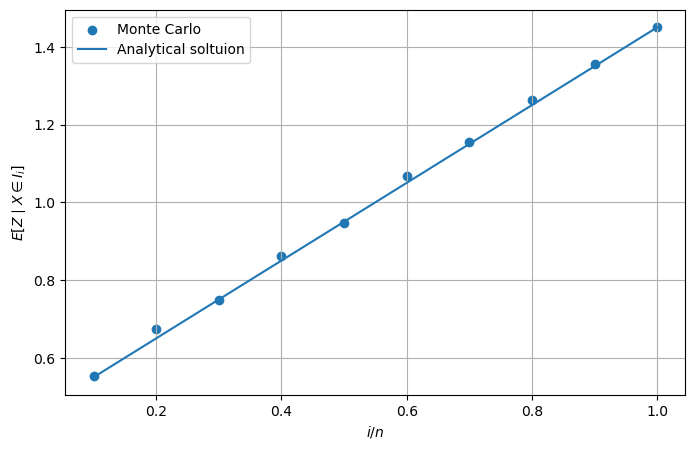

In [3]:
N = 10000
n = 10

X = np.random.uniform(0, 1, N)

Y = np.random.uniform(0, 1, N)
meanY = np.mean(Y)

Z = X+Y

Zlist = np.array([])

for i in range(1, n + 1):
    mask = (X >= (i-1)/n) & (X <= i/n)
    Zlist = np.append(Zlist, np.mean(Z[mask]))

Zlist 


i_vals = np.arange(1, n + 1)
x_vals = i_vals / n

closed_form = 0.5 + (2*i_vals - 1) / (2*n)

plt.figure(figsize=(8, 5))

plt.scatter(x_vals, Zlist, label="Monte Carlo")
plt.plot(x_vals, closed_form, label="Analytical soltuion")

plt.xlabel(r"$i/n$")
plt.ylabel(r"$E[Z \mid X \in I_i]$")
plt.legend()
plt.grid(True)
plt.show()


### Exercise 4

With the same arguments and calculations of the analtical solution of the precious problem we can now conclude the following.

$$E {\{Z | X \}}=E {\{X +Y | X \}}=E {\{X | X \}}+E {\{Y | X \}}=X +E {\{Y \}}=X +\frac{1}{2}$$

From here we can conlcude that a fucntion $g(X)$ sattsifying $g(X) = E {\{Z | X \}}$ is givne as $g(X)= X +\frac{1}{2}$.

The contour lines of the function $g(X)$ can be found below.

Locator attempting to generate 1001 ticks ([0.5, ..., 1.5]), which exceeds Locator.MAXTICKS (1000).


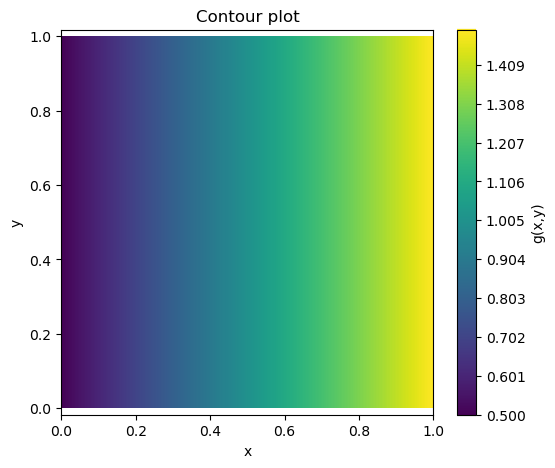

In [4]:
def g(x, y):
    return x + 1/2


x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)

import matplotlib.pyplot as plt

xx, yy = np.meshgrid(x, y)
zz = g(xx, yy)

plt.figure(figsize=(6, 5))
plt.contour(xx, yy, zz, levels=1000)
plt.colorbar(label="g(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour plot")
plt.axis("equal")
plt.show()

We are now interested in veryfying the followign statement.

$$
\int_H g(X(\omega))\,dP(\omega)
=
\int_H Z(\omega)\,dP(\omega)
$$

We let $H$ given as $$H=\left\{\omega\in\Omega:X(\omega)\in[a,b],\;Y(\omega)\in[a'=0,b'=1]\right\}$$

Note that $H \in \sigma (X)$.

Now we will calculate the two integrals and verify that they indeed are equal to each other.


$$\int_{\textcolor{white}{H}}^{}g\left(X\left(\omega \right)\right)d P\left(\omega \right)=\int_{0}^{1}\int_{a}^{b}x+\frac{1}{2}d xd y=\int_{0}^{1}\left(\int_{a}^{b}\frac{1}{2}\mathit{dx}+\int_{a}^{b}\mathrm{xdx}\right)d y=\int_{0}^{1}\left(\left(\frac{b}{2}-\frac{a}{2}\right)+\left(-\frac{a^{2}}{2}+\frac{b^{2}}{2}\right)\right)d y=\frac{1}{2} b-\frac{1}{2} a-\frac{1}{2} a^{2}+\frac{1}{2} b^{2}$$


$$\int_{\textcolor{white}{H}}^{}Z (\omega)d P (\omega)=\int_{0}^{1}\int_{a}^{b}x +\mathrm{y}d x d y =\int_{0}^{1}(\int_{a}^{b}\mathit{ydx} +\int_{a}^{b}\mathrm{xdx})d y =\int_{0}^{1}(\mathit{yb} -\mathit{ya} +\frac{b^{2}}{2}-\frac{a^{2}}{2})d y =\frac{1}{2} b -\frac{1}{2} a -\frac{1}{2} a^{2}+\frac{1}{2} b^{2}$$


We have now shown that $\int_{\textcolor{white}{H}}^{}g (X (\omega))d P (\omega)=\int_{\textcolor{white}{H}}^{}Z (\omega)d P (\omega)$.

### Exercise 5

We are now interested in finding a function $h (Z)=E {\{X | Z \}}$. Consider the following.

$$E {\{X | Z \}}+E {\{Y | Z \}}=E {\{X +Y | Z \}}=E {\{Z | Z \}}=Z$$

From here we can conclude that $E {\{X | Z \}}=Z -E {\{Y | Z \}}$. But as we showd in the start of the notebook, we had that $E {\{X | Z \}}=E {\{Y | Z \}}$. Therefore we get the following.

$$E {\{X | Z \}}=Z -E {\{X | Z \}}\Rightarrow 2E {\{X | Z \}}=Z $$

Thus we have found $h (Z)=E {\{X | Z \}}=\frac{1}{2}Z$

Now we can make the same numerical estimation as in exercise 3 and verify that we get the same results by the numerical approximation.

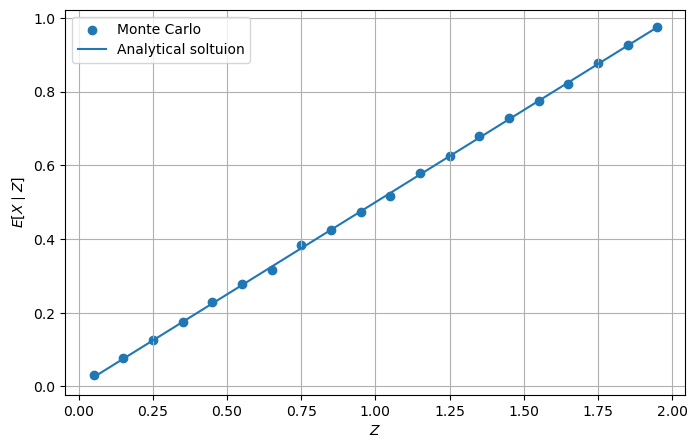

In [5]:
N = 10000
n = 20

X = np.random.uniform(0, 1, N)

Y = np.random.uniform(0, 1, N)

Z = X+Y

Xlist = np.array([])

for i in range(1, n + 1):
    mask = (Z >= 2*(i-1)/n) & (Z <= 2*i/n)
    Xlist = np.append(Xlist, np.mean(X[mask]))

 


i_vals = np.arange(1, n + 1)
x_vals = i_vals / n


closed_form = 0.5*Z


###
x_vals = 2*(i_vals - 0.5)/n
closed_form = 0.5*x_vals
###


plt.figure(figsize=(8, 5))

plt.scatter(x_vals, Xlist, label="Monte Carlo")
plt.plot(x_vals, closed_form, label="Analytical soltuion")

plt.xlabel(r"$Z$")
plt.ylabel(r"$E[X \mid Z]$")
plt.legend()
plt.grid(True)
plt.show()


We are now interested in veryfying the equation below, just as last exercise.

$$
\int_{\textcolor{white}{H}}^{}h (Z)d P (\omega)=\int_{\textcolor{white}{H}}^{}X d P (\omega)
$$

We let $H$ given as $$H ={\{\omega \in \Omega \colon Z (\omega)\in [a ,b]\}}$$

With $a ,b \in [0,2]$ and $a<b$

Now we will calculate the two integrals and verify that they indeed are equal to each other.

We will assume that we are looking at small set of a "thin" set of the image domain of $Z$. Note that $Z(\omega) = [0,2]$. Therefore we will look at the set given as $[z,z+\delta]$ $z<2$. Its clear that there exist a $ \delta > 0$ such that $[z,z+\delta] \in [0,2]$ for all $z$ satysfying $0 \le z <2$. Therefore we can rewrtie $H$ as given below.

$$H ={\{\omega \in \Omega \colon z \le x +y \le z +\delta \}}$$

From here there are two cases we have to investiagate.

1.  First case is tht $z+\delta \le 1$. 
2.  Second case $z<1, 1 < z + \delta$.
3.  Third case $1<z$


Here we will solve the problem for the first scenario, the solutions for the second and third scenario can be computed by the same idea of the solution of the first methode.

For solving the first case we will first come with an geometric argument, that will help us computing the integrals. Consider the plot below.

<p align="center"><img src="Images/IntegralPlot.jpg" width="300"></p>

$H$ can be seen as the blue set on the domain for some given $z$ and $\delta$ (for scenario 1). Now we are interested in computing the integrak of the integrand on the blue are. This is equivavelent on computing the integral on the blue and green area, and the subtracting the integral on the green area. This may seem as overcomplicating the task, but computing integrals of right angled triangles on $\mathbb{R}^{2}$ is much easier. Integrating a funcion $f(x,y)$ on a right-angled triangle with the end points of the triangle given as $(0,0)$, $(a,0)$, and $(0,b)$, is given as the following:

$$
\int_0^a \int_0^{b\left(1-\frac{x}{a}\right)} f(x,y)\,dy\,dx
$$

Using this equation we can begin to compute the integrals.

$$\int_{\textcolor{white}{H}}^{}h (Z)d P (\omega)=\int_{0}^{z +\delta}\int_{0}^{(z +\delta)\cdot (1-\frac{x}{z +\delta})}\frac{1}{2}(x +y)d y d x -\int_{0}^{z}\int_{0}^{z \cdot (1-\frac{x}{z})}\frac{1}{2}(x +y)d y d x =\frac{(z +\delta)^{3}}{6}-\frac{z^{3}}{6}$$

$$\int_{\textcolor{white}{H}}^{}X d P (\omega)=\int_{0}^{z +\delta}\int_{0}^{(z +\delta)\cdot (1-\frac{x}{z +\delta})}\mathrm{x}d y d x -\int_{0}^{z}\int_{0}^{z \cdot (1-\frac{x}{z})}\mathrm{x}d y d x =\frac{(z +\delta)^{3}}{6}-\frac{z^{3}}{6}$$



Same idea can be used for the other two scenarios to show that the two integrals indeed satisfies each other.

### Exercise 6

We are now interested in veryfying the tower proptery. For this example we are interested in veryfrying that $\mathbb{E}[\mathbb{E}[X \mid Z]] = \mathbb{E}[X]$
. Based on our previous simulations we can now compute these two values.

In [6]:
print("E[E[X|Z]]=", 1/2 * np.mean(Z))
print("E[X]=", np.mean(X))

E[E[X|Z]]= 0.500495573273127
E[X]= 0.5008708362773877


### Exercise 7

We are interested in findind $V[X|Z]$, not that the variance of a uniform distribution from a to b are given as $(b-a)^2/12$.

Now consider the case were $z<1$, then we have that $0 \le X(\omega) \le z$. Therfore $V[X|Z] = (z)^2/12$.

If we had that $1<z$ we would have that $z-1 \le X(\omega) \le 1$. Therfore we get $V[X|Z] = (2-z)^2/12$

Now we can compute these expectatiosn nummericaly and plot them against the analytical solution.

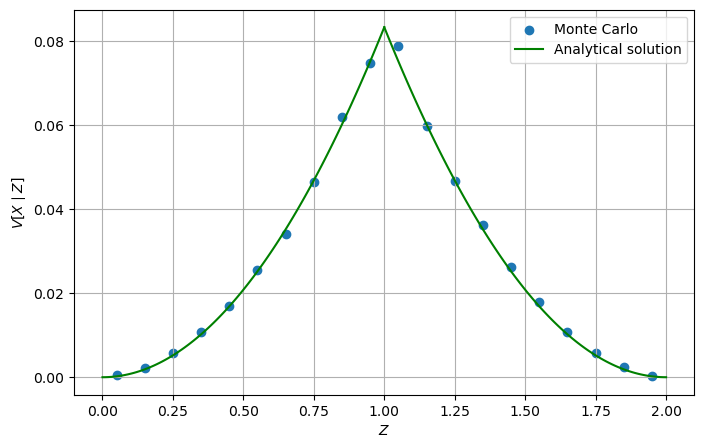

In [7]:
def V1(z):
    return z**2 / 12

def V2(z):
    return (2-z)**2 / 12


VXlist = np.array([])

for i in range(1, n + 1):
    mask = (Z >= 2*(i-1)/n) & (Z <= 2*i/n)
    VXlist = np.append(VXlist, np.var(X[mask]))


z1 = np.linspace(0, 1, 100)
z2 = np.linspace(1, 2, 100)

z_vals = 2*(np.arange(1, n + 1) - 0.5)/n


plt.figure(figsize=(8, 5))

plt.scatter(z_vals, VXlist, label="Monte Carlo")

plt.plot(z1, V1(z1), color="green")
plt.plot(z2, V2(z2), label="Analytical solution",  color="green")

plt.xlabel(r"$Z$")
plt.ylabel(r"$V[X\mid Z]$")
plt.legend()
plt.grid(True)

plt.show()

We will now verify the Variance decomposition foruma given as the following.

$$\mathbf{V}\{X\} = \mathbf{EV}\{X \mid Z\} + \mathbf{VE}\{X \mid Z\}$$


In [8]:
EXlist = np.array([])
p = np.array([])

for i in range(1, n + 1):
    mask = (Z >= 2*(i-1)/n) & (Z <= 2*i/n)

    EXlist = np.append(EXlist, np.mean(X[mask]))
    p = np.append(p, np.mean(mask))

EV = np.sum(p * VXlist)

VE = np.sum(p * (EXlist - np.mean(X))**2)


right = EV + VE

print("V(X) =", np.var(X))
print("E[V(X|Z)] + V(E[X|Z]) =", EV + VE)

V(X) = 0.08429354367192636
E[V(X|Z)] + V(E[X|Z]) = 0.08429354367192635
